# DCF Model

## 1. Intuition

DCF answers:

> “What is the company worth based on future cash it will generate?”

## 2. Mathematics

## 3. Implementation

In [1]:
def project_fcf(fcf0, growth, years):
    return [fcf0 * (1 + growth)**t for t in range(1, years+1)]

def terminal_value(fcf_last, g, r):
    return fcf_last * (1 + g) / (r - g)

def dcf(fcf0, growth, r, g_terminal, years):
    fcfs = project_fcf(fcf0, growth, years)

    discounted = [fcf / (1 + r)**(i+1) for i, fcf in enumerate(fcfs)]

    tv = terminal_value(fcfs[-1], g_terminal, r)
    tv_discounted = tv / (1 + r)**years

    return sum(discounted) + tv_discounted

## 4. Example (Nestlé-like)

In [2]:
fcf0 = 10_000  # CHF millions
growth = 0.04
r = 0.06
g_terminal = 0.02
years = 5

value = dcf(fcf0, growth, r, g_terminal, years)
value

279074.2364122035

## 5. Sensitivity Analysis

In [4]:
import numpy as np
import pandas as pd

wacc_values = np.linspace(0.05, 0.08, 10)
growth_values = np.linspace(0.02, 0.05, 10)

results = []

for w in wacc_values:
    row = []
    for g in growth_values:
        val = dcf(fcf0, g, w, 0.02, 5)
        row.append(val)
    results.append(row)

df = pd.DataFrame(results, index=wacc_values, columns=growth_values)
df


,0.020000,0.023333,0.026667,0.030000,0.033333,0.036667,0.040000,0.043333,0.046667,0.050000
0.050000,340000.000000,345280.444717,350628.136497,356043.725019,361527.864155,367081.211988,372704.430822,378398.187198,384163.151906,390000.000000
0.053333,306000.000000,310723.186698,315506.327907,320350.001908,325254.790709,330221.280064,335250.059480,340341.722232,345496.865372,350716.089746
0.056667,278181.818182,282449.398140,286770.972976,291147.062638,295578.190423,300064.882993,304607.670380,309207.086000,313863.666666,318577.952592
0.060000,255000.000000,258888.206699,262825.448222,266812.195983,270848.924429,274936.111056,279074.236412,283263.784112,287505.240842,291799.096377
0.063333,235384.615385,238952.085461,242564.399113,246221.986758,249925.281580,253674.719542,257470.739391,261313.782672,265204.293735,269142.719739
0.066667,218571.428571,221864.229567,225198.286865,228573.995803,231991.754259,235451.962662,238955.023996,242501.343809,246091.330226,249725.393951
0.070000,204000.000000,207054.982201,210148.116523,213279.767963,216450.303860,219660.093902,222909.510138,226198.926982,229528.721221,232899.272023
0.073333,191250.000000,194097.100815,196979.642011,199897.962087,202852.401713,205843.303737,208871.013193,211935.877304,215038.245496,218178.469398
0.076667,180000.000000,182663.870587,185360.792929,188091.082195,190855.055573,193653.032278,196485.333556,199352.282693,202254.205020,205191.427921
0.080000,170000.000000,172501.180046,175033.292418,177596.631594,180191.493935,182818.177693,185476.983020,188168.211969,190892.168502,193649.158498


## 6. Visualization

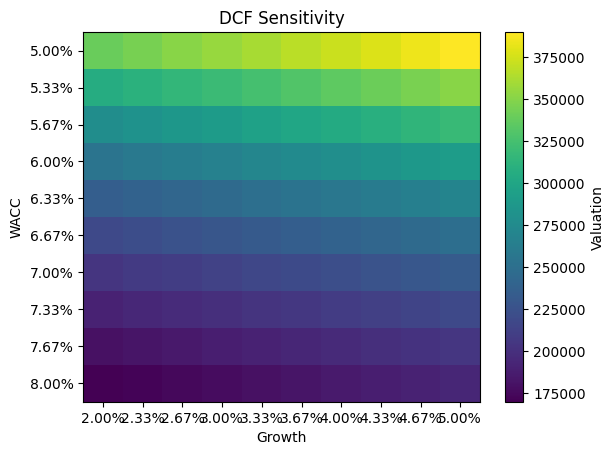

In [6]:
import matplotlib.pyplot as plt

plt.imshow(df, aspect='auto')
plt.colorbar(label="Valuation")
plt.xticks(range(len(growth_values)), [f"{g:.2%}" for g in growth_values])
plt.yticks(range(len(wacc_values)), [f"{w:.2%}" for w in wacc_values])
plt.xlabel("Growth")
plt.ylabel("WACC")
plt.title("DCF Sensitivity")
plt.show()


## 7. Application
- Equity research
- Investment decisions
- Fair value estimation

## 8. Reflection
- DCF is assumption-driven
- Terminal value dominates (~70–90%)
- WACC is the primary driver
- Always validate with:
  - market multiples
  - analyst expectations